In [1]:
!pip install opencv-python

In [12]:
FILE_PATH = "CUB_200_2011.tgz"
!tar -xvzf "{FILE_PATH}" -C .

attributes.txt
CUB_200_2011/
CUB_200_2011/images/
CUB_200_2011/images/001.Black_footed_Albatross/
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0010_796097.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0032_796115.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0057_796106.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0036_796127.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0060_796076.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0019_796104.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0069_796139.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0089_796069.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0071_796113.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0077_796114.jpg
CUB_200_2011/images/001.Black_footed_Albat

CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0017_796098.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0063_796141.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0007_796138.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0067_170.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0009_34.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0040_796066.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0026_796095.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0024_796089.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0065_796068.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0046_18.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0050_796125.jpg
CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albat

In [2]:
!pip install opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 42.2 MB/s  0:00:016m0:00:010:01


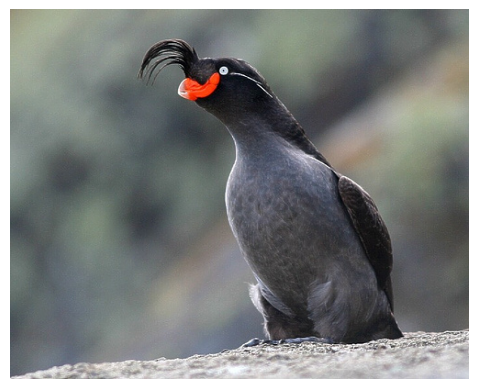

In [6]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(
    "CUB_200_2011/images/005.Crested_Auklet/Crested_Auklet_0070_785261.jpg"
)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

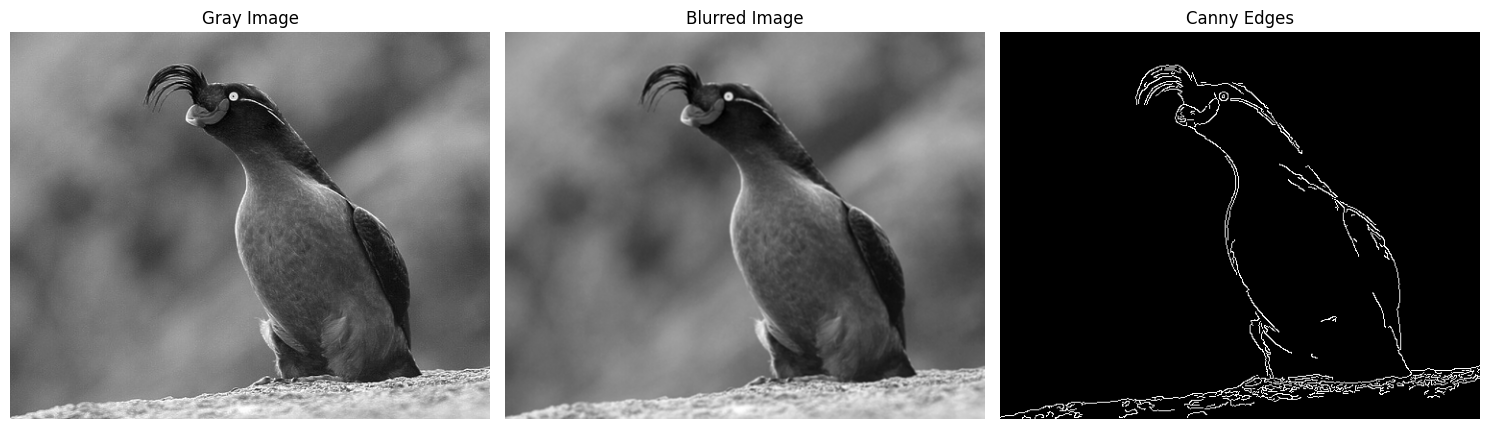

In [7]:

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (3,3), 0)
edges = cv2.Canny(
    image=img_blur,
    threshold1=100,
    threshold2=200
)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Gray Image")
axes[0].axis("off")

axes[1].imshow(img_blur, cmap='gray')
axes[1].set_title("Blurred Image")
axes[1].axis("off")

axes[2].imshow(edges, cmap='gray')
axes[2].set_title("Canny Edges")
axes[2].axis("off")

plt.tight_layout()
plt.show()

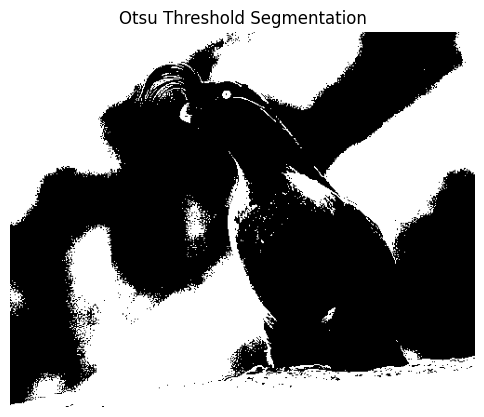

In [ ]:
#segmentation
ret, thresh = cv2.threshold(
    img_gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap='gray')
plt.title("Otsu Threshold Segmentation")
plt.axis("off")
plt.show()

# Segmentation

In [15]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(299.5), np.float64(258.5), np.float64(-0.5))

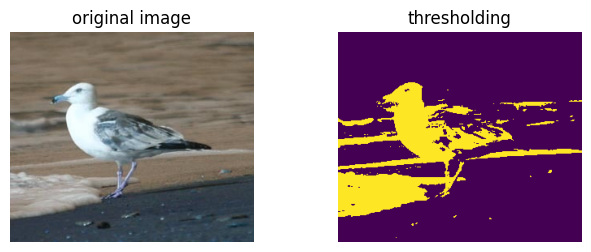

In [17]:
#thresholding
test_img = cv2.imread("CUB_200_2011/images/065.Slaty_backed_Gull/Slaty_Backed_Gull_0003_796032.jpg")
image_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img_gray = cv2.cvtColor(test_img,cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(12,6))
plt.subplot(231)
plt.imshow(test_img)
plt.title('original image')
plt.axis('off')

_, thresh = cv2.threshold(test_img_gray, 127, 255, cv2.THRESH_BINARY)
plt.subplot(232)
plt.imshow(thresh)
plt.title('thresholding')
plt.axis('off')

(77700, 3)


(np.float64(-0.5), np.float64(299.5), np.float64(258.5), np.float64(-0.5))

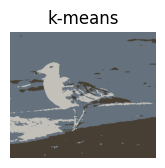

In [19]:
# kmeans
pixel_values = image_rgb.reshape((-1,3))
pixel_values = np.float32(pixel_values)
print(pixel_values.shape)

k = 3
kmeans = KMeans(n_clusters=k)
labels = kmeans.fit_predict(pixel_values)

centers = np.uint8(kmeans.cluster_centers_)
segmented = centers[labels.flatten()]
segmented_image = segmented.reshape(image_rgb.shape)

plt.subplot(231)
plt.imshow(segmented_image)
plt.title('k-means')
plt.axis('off')

(np.float64(-0.5), np.float64(299.5), np.float64(258.5), np.float64(-0.5))

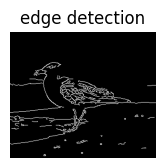

In [20]:
# edge detection
edges = cv2.Canny(test_img_gray, 100, 200)
plt.subplot(233)
plt.imshow(edges, cmap='gray')
plt.title('edge detection')
plt.axis('off')

(np.float64(-0.5), np.float64(299.5), np.float64(258.5), np.float64(-0.5))

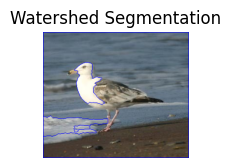

In [21]:
# watershed
img = test_img.copy()
gray_ws = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh_ws = cv2.threshold(gray_ws,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh_ws, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening,kernel,iterations=3)

dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)
_, sure_fg = cv2.threshold(dist_transform,0.7*dist_transform.max(),255,0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)

_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown==255] = 0

markers = cv2.watershed(img,markers)
img[markers == -1] = [255,0,0]

plt.subplot(235)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis("off")


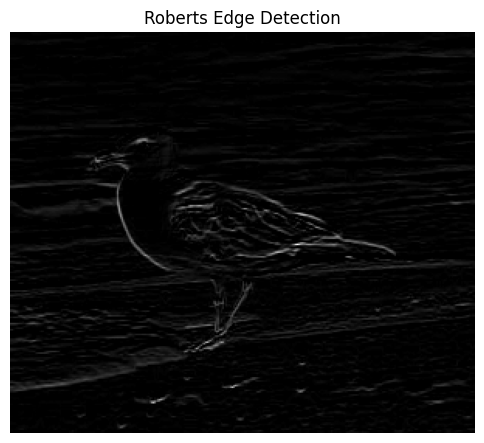

In [23]:
# edge detection roberts
# Roberts Cross kernels
roberts_cross_v = np.array([
    [1, 0],
    [0,-1]
], dtype=np.float32)

roberts_cross_h = np.array([
    [0, 1],
    [-1,0]
], dtype=np.float32)

# Apply filters
vertical = cv2.filter2D(
    test_img_gray,
    -1,
    roberts_cross_v
)

horizontal = cv2.filter2D(
    test_img_gray,
    -1,
    roberts_cross_h
)
roberts = cv2.addWeighted(
    vertical,
    0.5,
    horizontal,
    0.5,
    0
)
plt.figure(figsize=(6,6))
plt.imshow(roberts, cmap='gray')
plt.title("Roberts Edge Detection")
plt.axis("off")
plt.show()

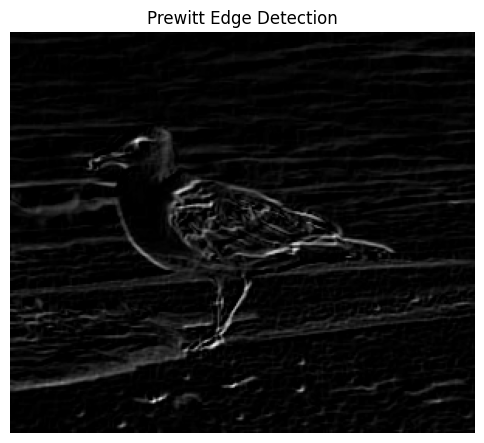

In [24]:
# Prewitt kernels
kernelx = np.array([
    [ 1, 0,-1],
    [ 1, 0,-1],
    [ 1, 0,-1]
], dtype=np.float32)

kernely = np.array([
    [ 1, 1, 1],
    [ 0, 0, 0],
    [-1,-1,-1]
], dtype=np.float32)

# Apply filters
prewitt_x = cv2.filter2D(
    test_img_gray,
    -1,
    kernelx
)

prewitt_y = cv2.filter2D(
    test_img_gray,
    -1,
    kernely
)

# Combine gradients
prewitt = cv2.addWeighted(
    prewitt_x,
    0.5,
    prewitt_y,
    0.5,
    0
)

# Display result
plt.figure(figsize=(6,6))

plt.imshow(prewitt, cmap='gray')

plt.title("Prewitt Edge Detection")

plt.axis("off")

plt.show()

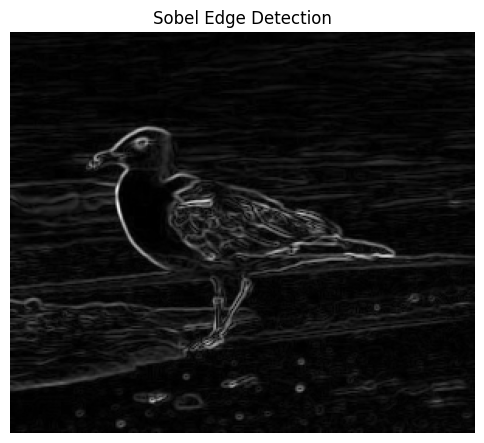

In [25]:
# Sobel gradients
sobelx = cv2.Sobel(
    test_img_gray,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)
sobely = cv2.Sobel(
    test_img_gray,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)
# Gradient magnitude
sobel = cv2.magnitude(sobelx, sobely)
# Display
plt.figure(figsize=(6,6))
plt.imshow(sobel, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis("off")
plt.show()

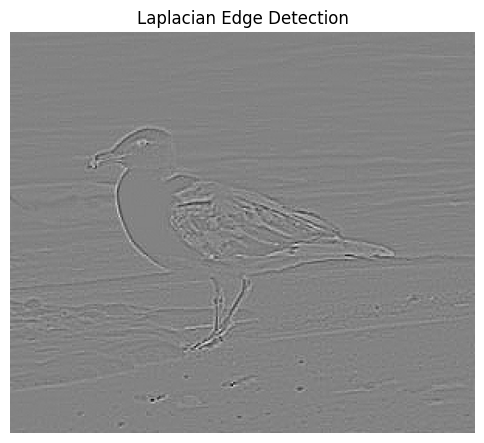

In [26]:
# Laplacian Edge Detection
laplacian = cv2.Laplacian(
    test_img_gray,
    cv2.CV_64F
)

# Display
plt.figure(figsize=(6,6))

plt.imshow(laplacian, cmap='gray')

plt.title("Laplacian Edge Detection")

plt.axis("off")

plt.show()

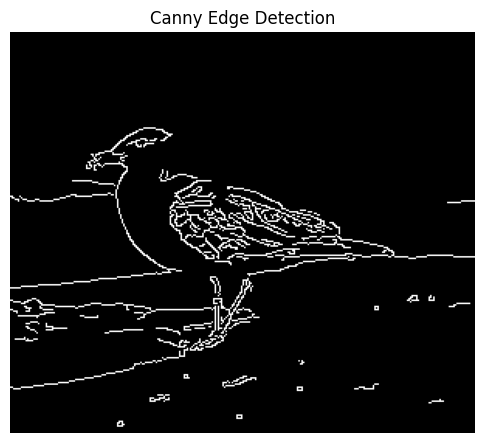

In [27]:
# Canny Edge Detection
canny = cv2.Canny(
    test_img_gray,
    100,
    200
)

# Display
plt.figure(figsize=(6,6))

plt.imshow(canny, cmap='gray')

plt.title("Canny Edge Detection")

plt.axis("off")

plt.show()

# Task 2 , download model vgg 19

In [29]:
import torch
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision import transforms
from numpy.fft import fft2, fftshift

In [30]:
model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
print(model)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /home/codespace/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100.0%


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [31]:
print(model.features)
layer = model.features[0]
filters = layer.weight.data.clone()
print(filters.shape)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

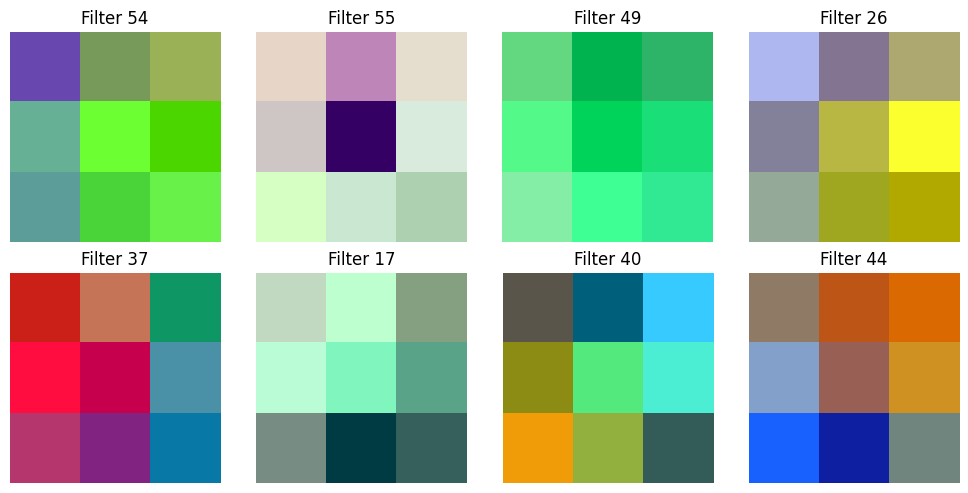

In [33]:
#plot 8 filters
import random
fig, axes = plt.subplots(2, 4, figsize=(10,5))
random_indices = random.sample(range(filters.shape[0]), 8)
for ax, idx in zip(axes.flat, random_indices):
    f = filters[idx]
    # Convert CHW → HWC
    f = f.permute(1,2,0)
    # Normalize
    f = (f - f.min()) / (f.max() - f.min())
    ax.imshow(f)
    ax.set_title(f'Filter {idx}')
    ax.axis('off')
plt.tight_layout()
plt.show()

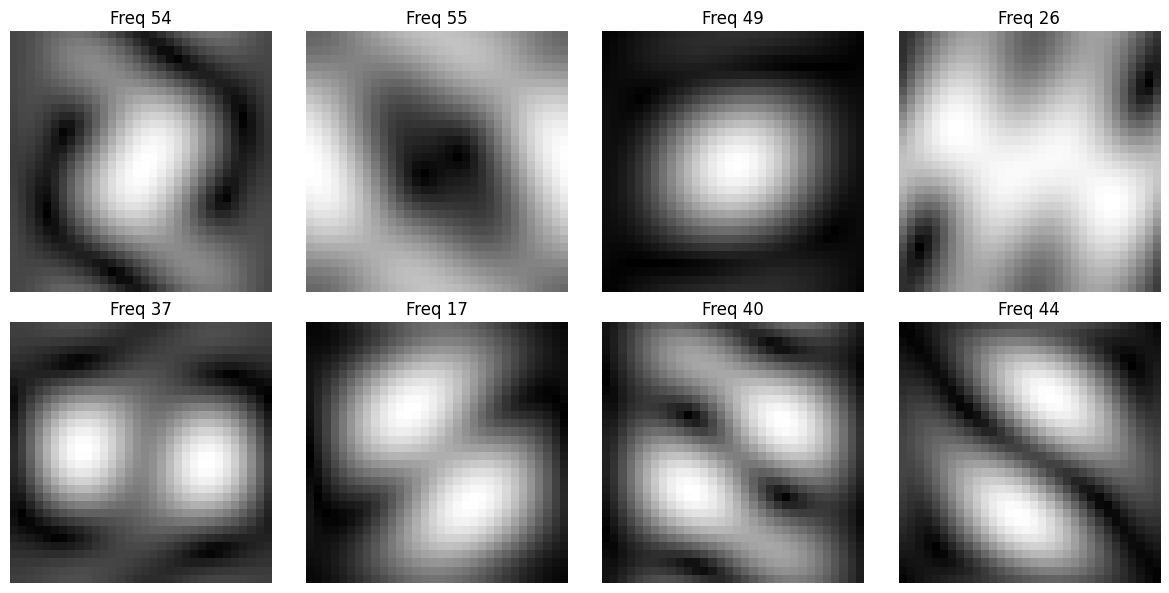

In [35]:
# plot frequency map
fig, axes = plt.subplots(2,4, figsize=(12,6))
for ax, idx in zip(axes.flat, random_indices):
    kernel = filters[idx,0].cpu().numpy()
    freq = np.abs(
        fftshift(
            fft2(kernel, s=(32,32))
        )
    )
    ax.imshow(freq, cmap='gray')
    ax.set_title(f'Freq {idx}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Task 3, Predict imagenet class for cub images

In [2]:
import os
import random
import torch
import torchvision.models as models
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

In [3]:
weights = models.VGG16_Weights.IMAGENET1K_V1
model = models.vgg16(weights=weights)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [4]:
transform = weights.transforms()
imagenet_classes = weights.meta["categories"]

In [5]:
dataset_path = "CUB_200_2011"
classes_file = os.path.join(dataset_path, "classes.txt")
cub_classes = {}
with open(classes_file, "r") as f:
    for line in f:
        idx, name = line.strip().split(" ", 1)
        cub_classes[int(idx)] = name

In [6]:
images_txt = os.path.join(dataset_path, "images.txt")
labels_txt = os.path.join(dataset_path, "image_class_labels.txt")
image_paths = {}
image_labels = {}
with open(images_txt) as f:
    for line in f:
        idx, path = line.strip().split(" ", 1)
        image_paths[int(idx)] = path
with open(labels_txt) as f:
    for line in f:
        idx, label = line.strip().split(" ")
        image_labels[int(idx)] = int(label)

In [7]:
random_classes = random.sample(list(cub_classes.keys()), 8)
selected_images = []
for cls in random_classes:
    candidates = [
        idx for idx, lbl in image_labels.items()
        if lbl == cls
    ]
    img_id = random.choice(candidates)
    selected_images.append((cls, img_id))

In [8]:
results = []
for cls, img_id in selected_images:
    img_path = os.path.join(
        dataset_path,
        "images",
        image_paths[img_id]
    )
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        out = model(x)
    pred_idx = out.argmax(1).item()
    pred_class = imagenet_classes[pred_idx]
    true_class = cub_classes[cls]
    results.append((img, true_class, pred_class))

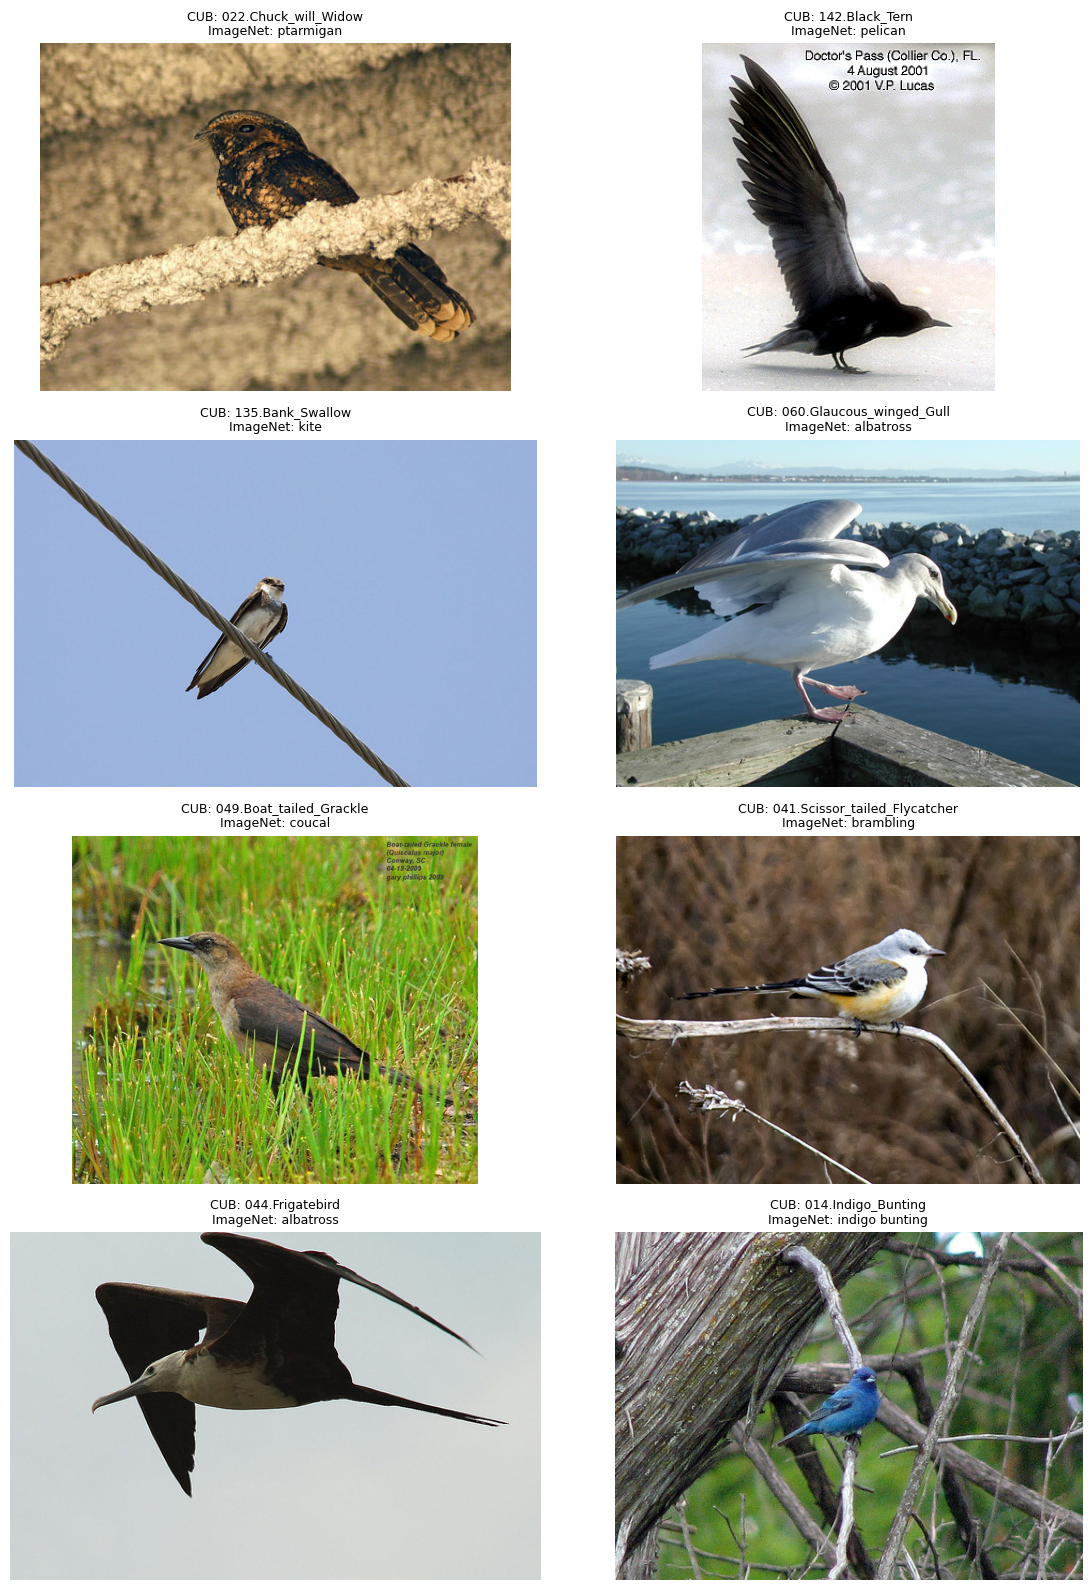

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(12,16))
for ax, (img, true_cls, pred_cls) in zip(axes.flat, results):
    ax.imshow(img)
    ax.set_title(
        f"CUB: {true_cls}\nImageNet: {pred_cls}",
        fontsize=9
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

# Task 4 - fine tune vgg for 200 classes

In [5]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.3 MB/s  0:00:006m0:00:01


In [3]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/857.3 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 7.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 20.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [pytorch-lightning]pytorch-lightning]


In [1]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torchvision.models as models
import pytorch_lightning as pl
import torchmetrics
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning import Trainer
from torch.utils.data import random_split


In [2]:
class CUBDataset(Dataset):
    def __init__(self, root_dir, train=True, transform=None):
        self.root = root_dir
        self.transform = transform

        images = pd.read_csv(os.path.join(root_dir,"images.txt"), sep=" ", names=["img_id","path"])
        labels = pd.read_csv(os.path.join(root_dir,"image_class_labels.txt"), sep=" ", names=["img_id","label"])
        split = pd.read_csv(os.path.join(root_dir,"train_test_split.txt"), sep=" ", names=["img_id","is_train"])

        data = images.merge(labels, on="img_id").merge(split, on="img_id")

        if train:
            data = data[data.is_train==1]
        else:
            data = data[data.is_train==0]

        self.data = data.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = os.path.join(self.root,"images",row.path)
        label = row.label - 1

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [3]:
class CUBDataModule(pl.LightningDataModule):

    def __init__(self, data_dir, batch_size=32):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size

        self.transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],
                                 [0.229,0.224,0.225])
        ])

    def setup(self, stage=None):

        full_train = CUBDataset(self.data_dir, train=True, transform=self.transform)

        train_size = int(0.8 * len(full_train))
        val_size = len(full_train) - train_size

        self.train_dataset, self.val_dataset = random_split(
            full_train, [train_size, val_size]
        )

        self.test_dataset = CUBDataset(
            self.data_dir, train=False, transform=self.transform
        )

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=32, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=32)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=32)

In [4]:
class VGG16FineTune(pl.LightningModule):

    def __init__(self, num_classes=200, lr=1e-4):
        super().__init__()

        self.lr = lr

        self.model = models.vgg16(pretrained=True)

        # freeze early layers
        for param in self.model.features[:20].parameters():
            param.requires_grad = False

        # replace classifier
        self.model.classifier[6] = nn.Linear(4096, num_classes)

        self.loss = nn.CrossEntropyLoss()

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self,x):
        return self.model(x)

    def training_step(self,batch,batch_idx):
        x,y = batch
        logits = self(x)

        loss = self.loss(logits,y)

        preds = torch.argmax(logits,dim=1)

        acc = self.train_acc(preds,y)

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):

      x, y = batch

      logits = self(x)

      loss = self.loss(logits, y)

      preds = torch.argmax(logits, dim=1)

      acc = self.val_acc(preds, y)

      self.log("val_loss", loss, prog_bar=True)
      self.log("val_acc", acc, prog_bar=True)

    def test_step(self,batch,batch_idx):
        x,y = batch
        logits = self(x)

        loss = self.loss(logits,y)

        preds = torch.argmax(logits,dim=1)

        acc = self.test_acc(preds,y)

        self.log("test_loss",loss, prog_bar=True)
        self.log("test_acc",acc, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.1,
            patience=3
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": scheduler,
            "monitor": "val_loss"
        }

In [5]:

data_dir = "CUB_200_2011"

data_module = CUBDataModule(data_dir, batch_size=32)

model = VGG16FineTune()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min"
)

checkpoint = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="best-vgg16-cub"
)

trainer = Trainer(
    max_epochs=50,
    accelerator="auto",
    callbacks=[early_stop, checkpoint],
    log_every_n_steps=10
)



/workspaces/cv-lab-2026/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/workspaces/cv-lab-2026/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/workspaces/cv-lab-2026/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts wit

In [6]:
trainer.fit(model, datamodule=data_module)


  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | model     | VGG                | 135 M  | train | 0    
1 | loss      | CrossEntropyLoss   | 0      | train | 0    
2 | train_acc | MulticlassAccuracy | 0      | train | 0    
3 | val_acc   | MulticlassAccuracy | 0      | train | 0    
4 | test_acc  | MulticlassAccuracy | 0      | train | 0    
-----------------------------------------------------------------
129 M     Trainable params
5.3 M     Non-trainable params
135 M     Total params
540.320   Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/workspaces/cv-lab-2026/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

[rank: 0] Received SIGTERM: 15


: 

In [ ]:
!find -name best-vgg16-cub.ckpt

In [ ]:
model = VGG16FineTune.load_from_checkpoint("./lightning_logs/version_4/checkpoints/best-vgg16-cub.ckpt")

In [ ]:
trainer.test(model, datamodule=data_module)